# Real Test

In [1]:
# Cell 1: Import necessary libraries
import numpy as np
from scipy import stats

In [20]:
# Cell 2: Define functions
def reconstruct_data(accuracy, frequency):
    """
    Reconstruct raw data (0s and 1s) from accuracy and frequency.
    
    :param accuracy: float, the accuracy value
    :param frequency: int, the number of trials
    :return: numpy array of 0s and 1s
    """
    num_correct = int(round(accuracy * frequency))
    data = np.array([1] * num_correct + [0] * (frequency - num_correct))
    np.random.shuffle(data)
    return data

def bootstrap_sample(data, sample_size, num_samples):
    """
    Perform bootstrap sampling on the data.
    
    :param data: numpy array, the original data
    :param sample_size: int, the size of each sample
    :param num_samples: int, the number of samples to generate
    :return: numpy array of sample means
    """
    return np.array([np.mean(np.random.choice(data, size=sample_size, replace=True))
                     for _ in range(num_samples)])

def compare_conditions(condition_a, condition_b, sample_size=200, num_samples=1000):
    """
    Compare two conditions using bootstrap sampling and t-test.
    
    :param condition_a: tuple of (accuracy, frequency) for condition A
    :param condition_b: tuple of (accuracy, frequency) for condition B
    :param sample_size: int, the size of each sample
    :param num_samples: int, the number of samples to generate
    :return: tuple of (t_statistic, p_value)
    """
    data_a = reconstruct_data(*condition_a)
    data_b = reconstruct_data(*condition_b)
    
    samples_a = bootstrap_sample(data_a, sample_size, num_samples)
    samples_b = bootstrap_sample(data_b, sample_size, num_samples)
    
    return stats.ttest_ind(samples_a, samples_b), samples_a, samples_b

In [21]:
unsup_data = {'normal': (0.4298412408759124, 548), 'jigsaw': (0.38349529190207154, 531), 'blur': (0.38055684007707125, 519), 'amount': (0.3930249042145594, 522)}
sup_data = {'normal': (0.4380560928433269, 517), 'jigsaw': (0.4019633911368016, 519), 'blur': (0.3962524654832347, 507), 'amount': (0.38167203219315904, 497)}

In [22]:

import matplotlib.pyplot as plt
def statistical_test(condition_a, condition_b, condition_a_label, condition_b_label): 
    
    condition_a = unsup_data['normal']
    condition_b = sup_data['normal']

    # Perform comparison
    (t_stat, p_value), samples_a, samples_b = compare_conditions(condition_a, condition_b)

    # Print results
    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_value}")

    if p_value < 0.05:
        print("The difference between conditions is statistically significant.")
    else:
        print("There is no statistically significant difference between conditions.")
    
    # Create histogram
    plt.figure(figsize=(10, 6))
    plt.hist(samples_a, bins=30, alpha=0.5, label= condition_a_label)
    plt.hist(samples_b, bins=30, alpha=0.5, label=condition_b_label)
    plt.xlabel('Accuracy')
    plt.ylabel('Frequency')
    plt.title('Distribution of Bootstrap Samples')
    plt.legend()
    plt.show()
    
    return (p_value, t_stat)

In this case, we perform the two-tailed t-test. 
The Hypotheses tested in this case: 

H0: μ1 = μ2

H1: μ1 ≠ μ2

T-statistic: -3.4005520897730226
P-value: 0.0006857285063203407
The difference between conditions is statistically significant.


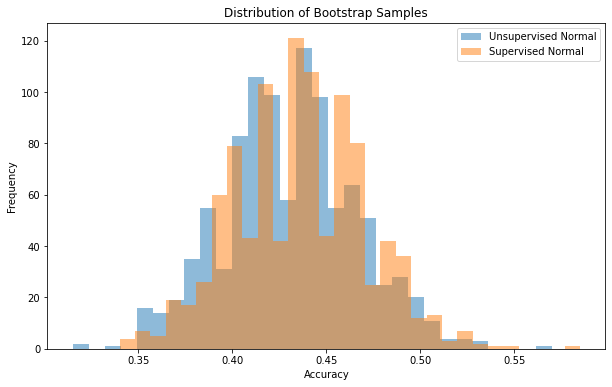

(0.0006857285063203407, -3.4005520897730226)

In [28]:
statistical_test(unsup_data['normal'], sup_data['normal'], 'Unsupervised Normal', 'Supervised Normal')

T-statistic: -4.741501300564106
P-value: 2.2713001072337165e-06
The difference between conditions is statistically significant.


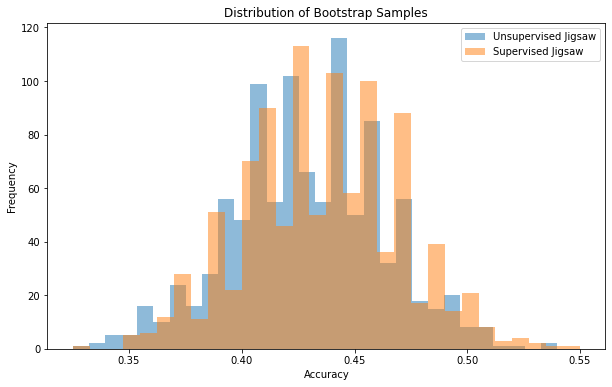

(2.2713001072337165e-06, -4.741501300564106)

In [6]:
statistical_test(unsup_data['jigsaw'], sup_data['jigsaw'], 'Unsupervised Jigsaw', 'Supervised Jigsaw')

T-statistic: -3.6879381552061696
P-value: 0.0002321163917743693
The difference between conditions is statistically significant.


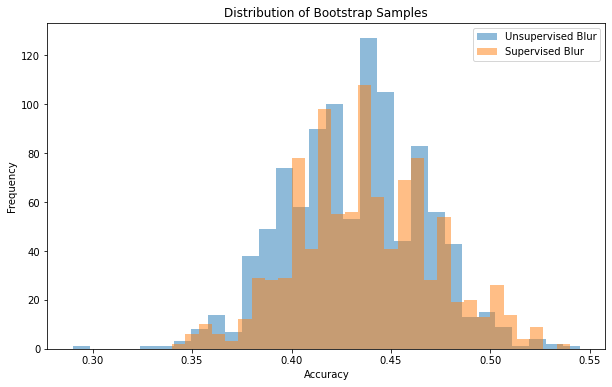

(0.0002321163917743693, -3.6879381552061696)

In [7]:
statistical_test(unsup_data['blur'], sup_data['blur'], 'Unsupervised Blur', 'Supervised Blur')

T-statistic: -4.313791084523982
P-value: 1.683038854572866e-05
The difference between conditions is statistically significant.


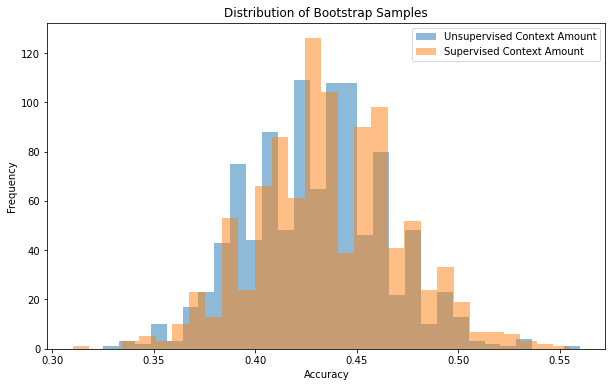

(1.683038854572866e-05, -4.313791084523982)

In [8]:
statistical_test(unsup_data['amount'], sup_data['amount'], 'Unsupervised Context Amount', 'Supervised Context Amount')

# One-Tail T-Test

In [34]:
from scipy import stats

def compare_conditions_one_tailed(condition_a, condition_b, condition_a_label, condition_b_label, sample_size=200, num_samples=1000, alternative='greater', alpha=0.05):
    """
    Compare two conditions using bootstrap sampling and one-tailed t-test, and provide a verdict.
    
    :param condition_a: tuple of (accuracy, frequency) for condition A
    :param condition_b: tuple of (accuracy, frequency) for condition B
    :param condition_a_label: str, label for condition A
    :param condition_b_label: str, label for condition B
    :param sample_size: int, the size of each sample
    :param num_samples: int, the number of samples to generate
    :param alternative: str, 'greater' or 'less', specifies the alternative hypothesis
    :param alpha: float, significance level for the test (default 0.05)
    :return: tuple of (t_statistic, p_value, samples_a, samples_b, verdict)
    """
    if alternative not in ['greater', 'less']:
        raise ValueError("alternative must be either 'greater' or 'less'")

    data_a = reconstruct_data(*condition_a)
    data_b = reconstruct_data(*condition_b)
    
    samples_a = bootstrap_sample(data_a, sample_size, num_samples)
    samples_b = bootstrap_sample(data_b, sample_size, num_samples)
    
    t_statistic, p_value = stats.ttest_ind(samples_a, samples_b, alternative=alternative)
    
    # Determine the verdict
    if p_value < alpha:
        if alternative == 'greater':
            verdict = f"Reject the null hypothesis. There is significant evidence to suggest that {condition_a_label} is greater than {condition_b_label} (p-value: {p_value:.4f})."
        else:  # alternative == 'less'
            verdict = f"Reject the null hypothesis. There is significant evidence to suggest that {condition_a_label} is less than {condition_b_label} (p-value: {p_value:.4f})."
    else:
        if alternative == 'greater':
            verdict = f"Fail to reject the null hypothesis. There is not enough evidence to conclude that {condition_a_label} is greater than {condition_b_label} (p-value: {p_value:.4f})."
        else:  # alternative == 'less'
            verdict = f"Fail to reject the null hypothesis. There is not enough evidence to conclude that {condition_a_label} is less than {condition_b_label} (p-value: {p_value:.4f})."

    return t_statistic, p_value, samples_a, samples_b, verdict

In [35]:
# Example usage
condition_a = (0.75, 100)  # (accuracy, frequency) for condition A
condition_b = (0.70, 100)  # (accuracy, frequency) for condition B

# Testing with the 'greater' alternative
t_stat, p_value, samples_a, samples_b, verdict = compare_conditions_one_tailed(
    condition_a,
    condition_b, 'Condition A', 'Condition B',
    alternative='greater'
)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
print(f"\nVerdict:\n{verdict}")

# You can also test the 'less' alternative
t_stat_less, p_value_less, samples_a_less, samples_b_less, verdict_less = compare_conditions_one_tailed(
    condition_a,
    condition_b, 'Condition A', 'Condition B',
    alternative='less'
)

print(f"\nTesting for 'less' alternative:")
print(f"T-statistic: {t_stat_less}")
print(f"P-value: {p_value_less}")
print(f"\nVerdict:\n{verdict_less}")

T-statistic: 35.995442753681814
P-value: 1.92774976363183e-219

Verdict:
Reject the null hypothesis. There is significant evidence to suggest that Condition A is greater than Condition B (p-value: 0.0000).

Testing for 'less' alternative:
T-statistic: 37.97109485707501
P-value: 1.0

Verdict:
Fail to reject the null hypothesis. There is not enough evidence to conclude that Condition A is less than Condition B (p-value: 1.0000).


# Random Testing

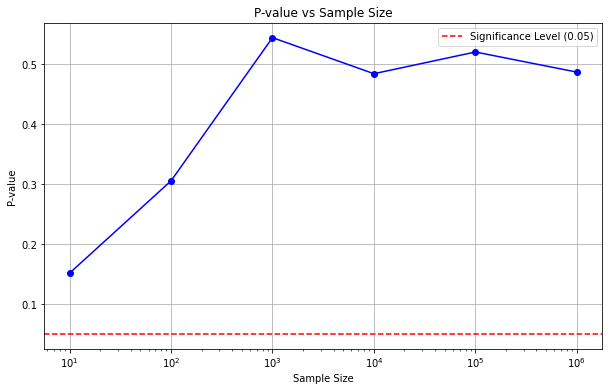

Sample Sizes: [10, 100, 1000, 10000, 100000, 1000000]
P-values: [0.151710255630401, 0.3055622066162651, 0.5442762749036092, 0.4842040541405961, 0.52037734541729, 0.4868757548301246]


In [19]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def run_t_test(n_samples):
    group1 = np.random.normal(100, 15, n_samples)
    group2 = np.random.normal(100, 15, n_samples)  # Only 0.5 difference in means
    t_stat, p_value = stats.ttest_ind(group1, group2)
    return p_value

sample_sizes = [10, 100, 1000, 10000, 100000, 1000000]
p_values = [run_t_test(n) for n in sample_sizes]

plt.figure(figsize=(10, 6))
plt.semilogx(sample_sizes, p_values, 'bo-')
plt.xlabel('Sample Size')
plt.ylabel('P-value')
plt.title('P-value vs Sample Size')
plt.axhline(y=0.05, color='r', linestyle='--', label='Significance Level (0.05)')
plt.legend()
plt.grid(True)
plt.show()

print("Sample Sizes:", sample_sizes)
print("P-values:", p_values)